In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('laptop_price.csv', encoding='latin-1')

In [3]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [4]:
df.shape

(1303, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [6]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [7]:
df.isnull().sum()

,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

In [10]:
df['Ram'] = df['Ram'].str.replace('GB','').astype(int)


In [11]:
df['Weight'] = df['Weight'].str.replace('kg','').astype(float)


In [12]:
category = ['Company','TypeName','ScreenResolution','Cpu','Memory','Gpu','OpSys']

In [13]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


In [14]:
df['Cpu'].value_counts()

,count
Cpu,
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core i5 7200U 2.70GHz,1
Intel Core M M7-6Y75 1.2GHz,1
Intel Core M 6Y54 1.1GHz,1


In [15]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [16]:
df_encoded = pd.get_dummies(df,columns = category,drop_first=True)

In [17]:
df_encoded

,laptop_ID,Product,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,1,MacBook Pro,13.3,8,1.37,1339.69,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,Macbook Air,13.3,8,1.34,898.94,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3,250 G6,15.6,8,1.86,575.00,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,MacBook Pro,15.4,16,1.83,2537.45,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,MacBook Pro,13.3,8,1.37,1803.60,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Yoga 500-14ISK,14.0,4,1.80,638.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1299,1317,Yoga 900-13ISK,13.3,16,1.30,1499.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1300,1318,IdeaPad 100S-14IBR,14.0,2,1.50,229.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1301,1319,15-AC110nv (i7-6500U/6GB/1TB/Radeon,15.6,6,2.19,764.00,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [18]:

df_encoded.head()

,laptop_ID,Product,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,1,MacBook Pro,13.3,8,1.37,1339.69,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,Macbook Air,13.3,8,1.34,898.94,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3,250 G6,15.6,8,1.86,575.00,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,MacBook Pro,15.4,16,1.83,2537.45,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,MacBook Pro,13.3,8,1.37,1803.60,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [19]:
df_encoded.drop(columns=['laptop_ID','Product'],inplace=True)

In [20]:
df_encoded = df_encoded.astype(int)

In [21]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Columns: 338 entries, Inches to OpSys_macOS
dtypes: int64(338)
memory usage: 3.4 MB


In [22]:
from sklearn.preprocessing import StandardScaler
numerical_features = ['Inches','Ram','Weight','Price_euros']
scaler = StandardScaler()
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [23]:
df_encoded['Inches']

,Inches
0,-1.161255
1,-1.161255
2,0.294363
3,0.294363
4,-1.161255
...,...
1298,-0.433446
1299,-1.161255
1300,-0.433446
1301,0.294363


In [24]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['Price_euros'])
y = df_encoded['Price_euros']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [26]:
X_train.shape

(1042, 337)

In [27]:
y_train.shape

(1042,)

In [28]:
#Building an ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
model = Sequential()

In [30]:
input_dim = X_train.shape[1]

model.add(Dense(units=128, activation='relu', input_shape=(input_dim,)))
model.add(Dropout(0.2))#hiddenlayer1

model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))#hiddenlayer2

model.add(Dense(units=64, activation='relu'))#hiddenlayer3
model.add(Dropout(0.2))

model.add(Dense(units=32, activation='relu')) #hiddenlayer 4
model.add(Dropout(0.2))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.add(Dense(units=1, activation='linear'))

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,145 (274.00 KB)

 Trainable params: 70,145 (274.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early = EarlyStopping(monitor='val_loss',patience=5,verbose=1)

In [34]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mean_absolute_error'])

In [35]:
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2,callbacks=[early])

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.9722 - mean_absolute_error: 0.7476 - val_loss: 0.4391 - val_mean_absolute_error: 0.4265
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4165 - mean_absolute_error: 0.4833 - val_loss: 0.3476 - val_mean_absolute_error: 0.3748
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3526 - mean_absolute_error: 0.4240 - val_loss: 0.3169 - val_mean_absolute_error: 0.3485
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2276 - mean_absolute_error: 0.3609 - val_loss: 0.2736 - val_mean_absolute_error: 0.3573
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2305 - mean_absolute_error: 0.3505 - val_loss: 0.2569 - val_mean_absolute_error: 0.3472
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2128 - mean_absolute_error: 0.3565 - val_loss: 0.2619 - val_mean_absolute_error: 0.3375
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1740 - mean_absolute_error: 0.3190 - val_los

In [36]:
y_pred = model.predict(X_test)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [37]:
y_pred_train = model.predict(X_train)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [41]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 0.166521009346238
Mean Absolute Error: 0.26175807862640527
R-squared: 0.8399245525336033


In [40]:
r2

0.8399245525336033

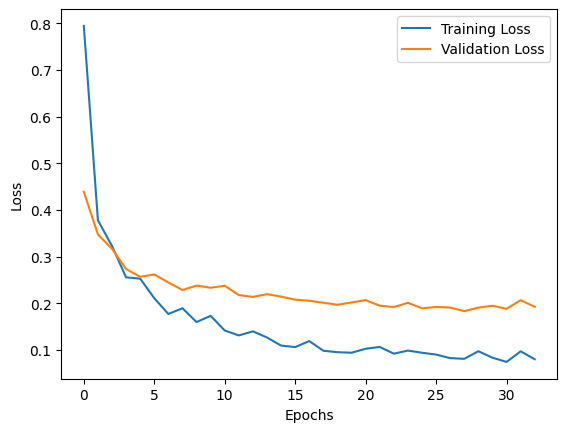

In [42]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()